In [502]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [503]:
df= pd.read_csv("laptop_data.csv")

In [504]:
df.head(1)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832


In [505]:
df.shape

(1303, 12)

In [506]:
df.tail()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [507]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [508]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [509]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [510]:
df.drop_duplicates(inplace=True)

In [511]:
df.shape

(1303, 12)

In [512]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [513]:
#y=df["price"]

In [514]:
#x=["company","typename","screenresolution","cpu","ram","memeory","gpu"]

FEATURE ENGINEERING

In [515]:
df["Ram"] = df['Ram'].str.replace("GB" , "")
df["Ram"] = df["Ram"].astype(int)

In [516]:
df["Weight"] = df["Weight"].str.replace("kg","")
df['Weight'] = df["Weight"].astype(float)

In [517]:
df["Gpu Brand"] = df["Gpu"].apply(lambda x:x.split()[0])
df.drop("Gpu", axis=1, inplace=True)

In [518]:
df["Cpu Brand"] = df["Cpu"].apply(lambda x:x.split()[0])
df.drop("Cpu", axis=1, inplace=True)

In [519]:
df.head(1)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Ram,Memory,OpSys,Weight,Price,Gpu Brand,Cpu Brand
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128GB SSD,macOS,1.37,71378.6832,Intel,Intel


In [520]:
df["OpSys"].values

array(['macOS', 'macOS', 'No OS', ..., 'Windows 10', 'Windows 10',
       'Windows 10'], shape=(1303,), dtype=object)

In [521]:
def os(text):
    if text=="Windows 10":
        return "Windows"
    elif text=="Windows 7":
        return "Windows"
    elif "macOS" in text:
        return "Mac"
    elif "Linux" in text:
        return "Linux"
    else:
        return "other"

df["os"] = df["OpSys"].apply(os)

df.drop("OpSys", axis=1, inplace=True)


In [522]:
df.head(1)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Weight,Price,Gpu Brand,Cpu Brand,os
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128GB SSD,1.37,71378.6832,Intel,Intel,Mac


In [523]:
df["ScreenResolution"].unique

<bound method Series.unique of 0               IPS Panel Retina Display 2560x1600
1                                         1440x900
2                                Full HD 1920x1080
3               IPS Panel Retina Display 2880x1800
4               IPS Panel Retina Display 2560x1600
                           ...                    
1298     IPS Panel Full HD / Touchscreen 1920x1080
1299    IPS Panel Quad HD+ / Touchscreen 3200x1800
1300                                      1366x768
1301                                      1366x768
1302                                      1366x768
Name: ScreenResolution, Length: 1303, dtype: object>

In [524]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [525]:
 df["Touchscreen"] = df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in x else 0)

In [526]:
 df["IPS"] = df["ScreenResolution"].apply(lambda x: 1 if "IPS" in x else 0)

In [527]:
new = df["ScreenResolution"].str.extract(r'(\d+)x(\d+)')
df["X_res"] = new[0].astype(int)
df["Y_res"] = new[1].astype(int)

In [528]:
df["PPI"] = np.sqrt(df["X_res"]**2 + df["Y_res"]**2)/ df["Inches"]

In [529]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Ram,Memory,Weight,Price,Gpu Brand,Cpu Brand,os,Touchscreen,IPS,X_res,Y_res,PPI
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,128GB SSD,1.37,71378.6832,Intel,Intel,Mac,0,1,2560,1600,226.983005
1,1,Apple,Ultrabook,13.3,1440x900,8,128GB Flash Storage,1.34,47895.5232,Intel,Intel,Mac,0,0,1440,900,127.677940
2,2,HP,Notebook,15.6,Full HD 1920x1080,8,256GB SSD,1.86,30636.0000,Intel,Intel,other,0,0,1920,1080,141.211998
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,16,512GB SSD,1.83,135195.3360,AMD,Intel,Mac,0,1,2880,1800,220.534624
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,8,256GB SSD,1.37,96095.8080,Intel,Intel,Mac,0,1,2560,1600,226.983005


In [530]:
df.drop(["ScreenResolution", "X_res", "Y_res", "Inches"], axis=1, inplace=True)

In [531]:
df.head()

,Unnamed: 0,Company,TypeName,Ram,Memory,Weight,Price,Gpu Brand,Cpu Brand,os,Touchscreen,IPS,PPI
0,0,Apple,Ultrabook,8,128GB SSD,1.37,71378.6832,Intel,Intel,Mac,0,1,226.983005
1,1,Apple,Ultrabook,8,128GB Flash Storage,1.34,47895.5232,Intel,Intel,Mac,0,0,127.677940
2,2,HP,Notebook,8,256GB SSD,1.86,30636.0000,Intel,Intel,other,0,0,141.211998
3,3,Apple,Ultrabook,16,512GB SSD,1.83,135195.3360,AMD,Intel,Mac,0,1,220.534624
4,4,Apple,Ultrabook,8,256GB SSD,1.37,96095.8080,Intel,Intel,Mac,0,1,226.983005


In [532]:
df["Memory"].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
1TB SSD                           14
512GB SSD +  1TB HDD              14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [533]:
import re

df["SSD"] = 0
df["HDD"] = 0
df["Flash"] = 0
df["Hybrid"] = 0

In [534]:
for i in range(len(df)):
    memory = df.loc[i, 'Memory']

    parts = memory.split(' + ')

    for part in parts:
        size = int(re.findall(r'\d+', part)[0])
        
        if 'TB' in part:
            size *= 1024
        if 'SSD' in part:
            df.loc[i, 'SSD'] += size
        elif 'HDD' in part:
            df.loc[i, 'HDD'] += size
        elif 'Flash Storage' in part:
            df.loc[i, 'Flash'] += size
        elif 'Hybrid' in part:
            df.loc[i, 'Hybrid'] += size

In [535]:
df.head(2)

,Unnamed: 0,Company,TypeName,Ram,Memory,Weight,Price,Gpu Brand,Cpu Brand,os,Touchscreen,IPS,PPI,SSD,HDD,Flash,Hybrid
0,0,Apple,Ultrabook,8,128GB SSD,1.37,71378.6832,Intel,Intel,Mac,0,1,226.983005,128,0,0,0
1,1,Apple,Ultrabook,8,128GB Flash Storage,1.34,47895.5232,Intel,Intel,Mac,0,0,127.677940,0,0,128,0


In [536]:
df.drop("Memory", axis=1, inplace=True)

In [537]:
df.head()

,Unnamed: 0,Company,TypeName,Ram,Weight,Price,Gpu Brand,Cpu Brand,os,Touchscreen,IPS,PPI,SSD,HDD,Flash,Hybrid
0,0,Apple,Ultrabook,8,1.37,71378.6832,Intel,Intel,Mac,0,1,226.983005,128,0,0,0
1,1,Apple,Ultrabook,8,1.34,47895.5232,Intel,Intel,Mac,0,0,127.677940,0,0,128,0
2,2,HP,Notebook,8,1.86,30636.0000,Intel,Intel,other,0,0,141.211998,256,0,0,0
3,3,Apple,Ultrabook,16,1.83,135195.3360,AMD,Intel,Mac,0,1,220.534624,512,0,0,0
4,4,Apple,Ultrabook,8,1.37,96095.8080,Intel,Intel,Mac,0,1,226.983005,256,0,0,0


PLOTS

<Axes: xlabel='Price', ylabel='Count'>

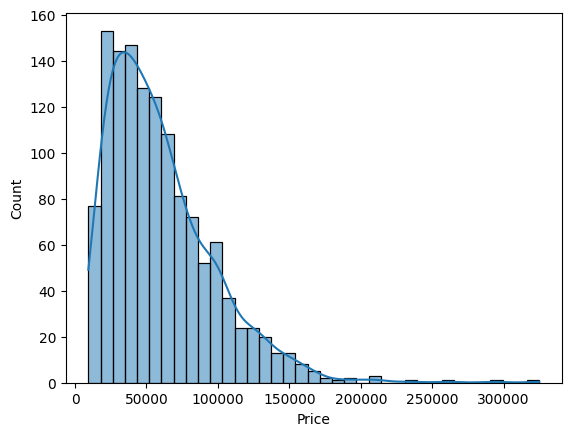

In [538]:
sns.histplot(df["Price"], kde= True)

<Axes: xlabel='Weight', ylabel='Count'>

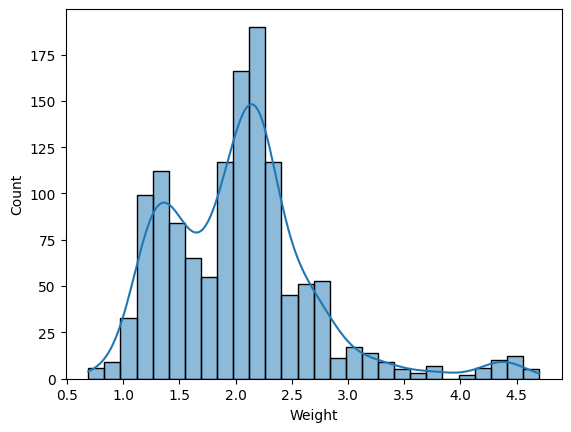

In [539]:
sns.histplot(df["Weight"], kde=True)

<Axes: xlabel='Ram', ylabel='Price'>

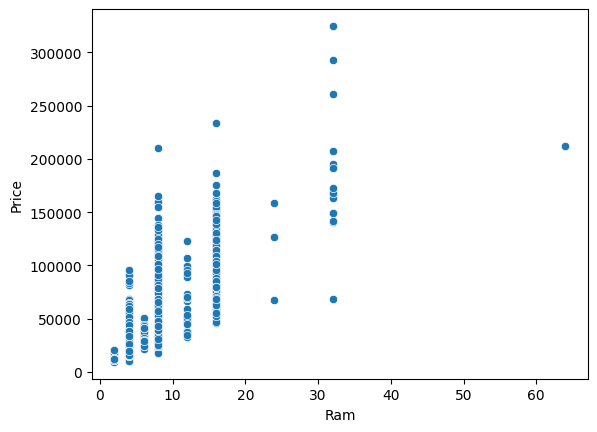

In [540]:
sns.scatterplot(x="Ram", y="Price", data=df)

<Axes: xlabel='Weight', ylabel='Price'>

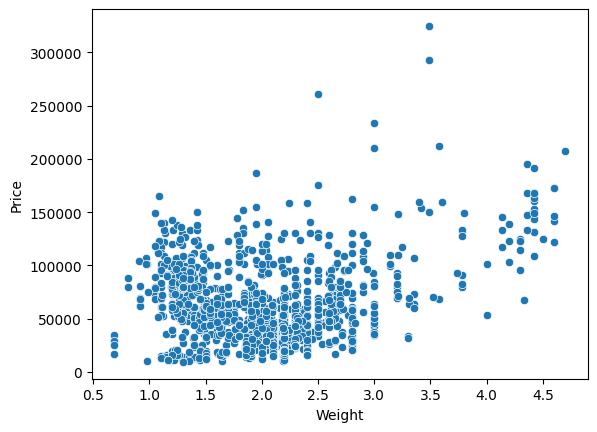

In [541]:
sns.scatterplot(x="Weight", y="Price", data=df)

<Axes: xlabel='PPI', ylabel='Price'>

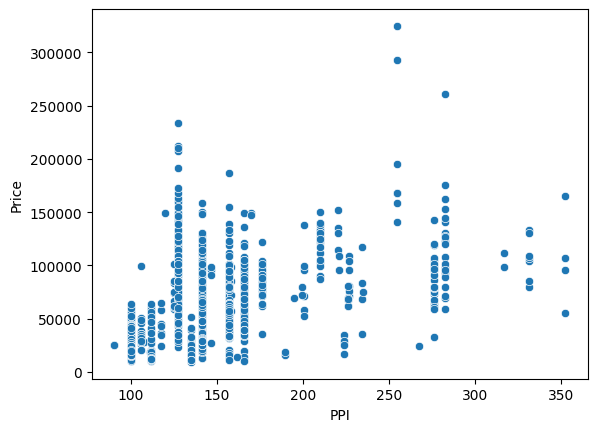

In [542]:
sns.scatterplot(x="PPI", y="Price", data=df)

<Axes: xlabel='Company', ylabel='Price'>

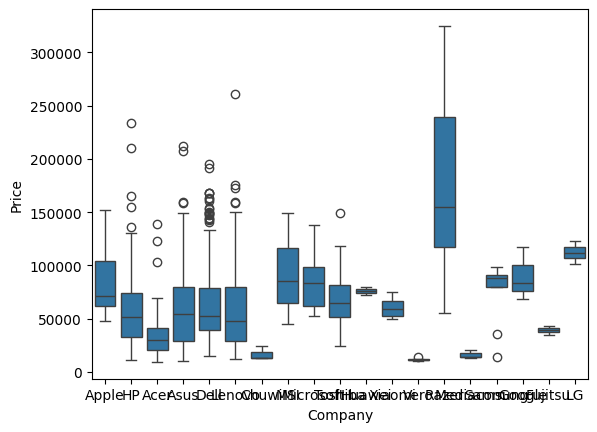

In [543]:
sns.boxplot(x='Company', y='Price', data=df)

<Axes: xlabel='TypeName', ylabel='Price'>

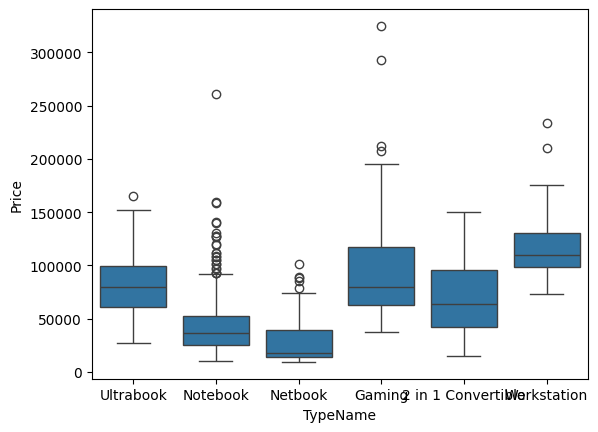

In [544]:
sns.boxplot(x='TypeName', y='Price', data=df)

<Axes: xlabel='os', ylabel='Price'>

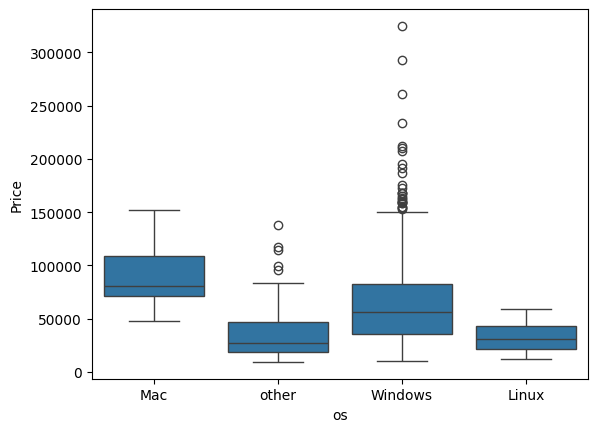

In [545]:
sns.boxplot(x='os', y='Price', data=df)

<Axes: xlabel='Ram', ylabel='Price'>

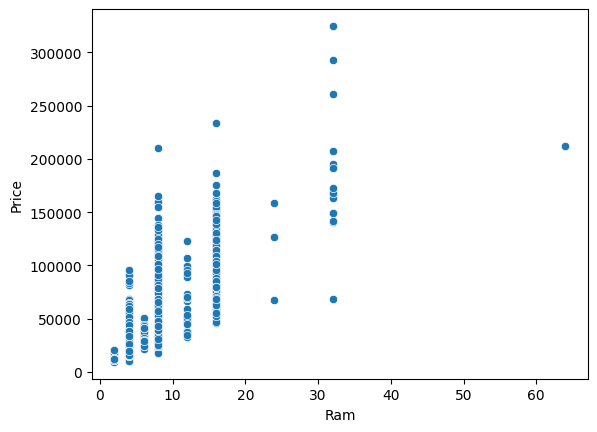

In [546]:
sns.scatterplot(x="Ram", y="Price", data=df)

<Axes: xlabel='Company', ylabel='count'>

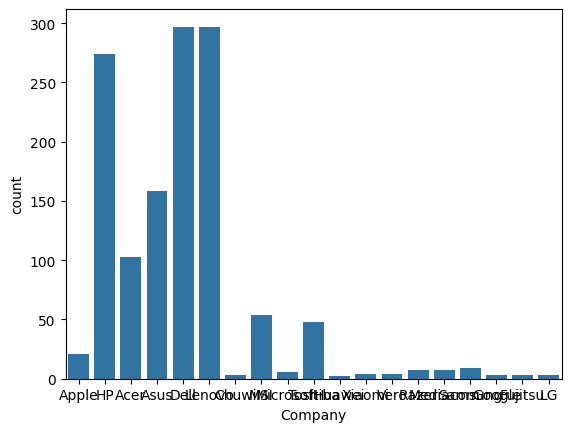

In [547]:
sns.countplot(x="Company", data=df)

In [548]:
df.dtypes

Unnamed: 0       int64
Company         object
TypeName        object
Ram              int64
Weight         float64
Price          float64
Gpu Brand       object
Cpu Brand       object
os              object
Touchscreen      int64
IPS              int64
PPI            float64
SSD              int64
HDD              int64
Flash            int64
Hybrid           int64
dtype: object

In [549]:
df = pd.get_dummies(df, drop_first = True)

In [550]:
df.head()

,Unnamed: 0,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Flash,...,TypeName_Ultrabook,TypeName_Workstation,Gpu Brand_ARM,Gpu Brand_Intel,Gpu Brand_Nvidia,Cpu Brand_Intel,Cpu Brand_Samsung,os_Mac,os_Windows,os_other
0,0,8,1.37,71378.6832,0,1,226.983005,128,0,0,...,True,False,False,True,False,True,False,True,False,False
1,1,8,1.34,47895.5232,0,0,127.677940,0,0,128,...,True,False,False,True,False,True,False,True,False,False
2,2,8,1.86,30636.0000,0,0,141.211998,256,0,0,...,False,False,False,True,False,True,False,False,False,True
3,3,16,1.83,135195.3360,0,1,220.534624,512,0,0,...,True,False,False,False,False,True,False,True,False,False
4,4,8,1.37,96095.8080,0,1,226.983005,256,0,0,...,True,False,False,True,False,True,False,True,False,False


In [551]:
bool_cols = df.select_dtypes(include = "bool").columns
df[bool_cols]=df[bool_cols].astype(int)

In [552]:
df.head()

,Unnamed: 0,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Flash,...,TypeName_Ultrabook,TypeName_Workstation,Gpu Brand_ARM,Gpu Brand_Intel,Gpu Brand_Nvidia,Cpu Brand_Intel,Cpu Brand_Samsung,os_Mac,os_Windows,os_other
0,0,8,1.37,71378.6832,0,1,226.983005,128,0,0,...,1,0,0,1,0,1,0,1,0,0
1,1,8,1.34,47895.5232,0,0,127.677940,0,0,128,...,1,0,0,1,0,1,0,1,0,0
2,2,8,1.86,30636.0000,0,0,141.211998,256,0,0,...,0,0,0,1,0,1,0,0,0,1
3,3,16,1.83,135195.3360,0,1,220.534624,512,0,0,...,1,0,0,0,0,1,0,1,0,0
4,4,8,1.37,96095.8080,0,1,226.983005,256,0,0,...,1,0,0,1,0,1,0,1,0,0


In [555]:
df.columns

Index(['Unnamed: 0', 'Ram', 'Weight', 'Price', 'Touchscreen', 'IPS', 'PPI',
       'SSD', 'HDD', 'Flash', 'Hybrid', 'Company_Apple', 'Company_Asus',
       'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google',
       'Company_HP', 'Company_Huawei', 'Company_LG', 'Company_Lenovo',
       'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer',
       'Company_Samsung', 'Company_Toshiba', 'Company_Vero', 'Company_Xiaomi',
       'TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook',
       'TypeName_Ultrabook', 'TypeName_Workstation', 'Gpu Brand_ARM',
       'Gpu Brand_Intel', 'Gpu Brand_Nvidia', 'Cpu Brand_Intel',
       'Cpu Brand_Samsung', 'os_Mac', 'os_Windows', 'os_other'],
      dtype='object')

In [556]:
df.head()

,Unnamed: 0,Ram,Weight,Price,Touchscreen,IPS,PPI,SSD,HDD,Flash,...,TypeName_Ultrabook,TypeName_Workstation,Gpu Brand_ARM,Gpu Brand_Intel,Gpu Brand_Nvidia,Cpu Brand_Intel,Cpu Brand_Samsung,os_Mac,os_Windows,os_other
0,0,8,1.37,71378.6832,0,1,226.983005,128,0,0,...,1,0,0,1,0,1,0,1,0,0
1,1,8,1.34,47895.5232,0,0,127.677940,0,0,128,...,1,0,0,1,0,1,0,1,0,0
2,2,8,1.86,30636.0000,0,0,141.211998,256,0,0,...,0,0,0,1,0,1,0,0,0,1
3,3,16,1.83,135195.3360,0,1,220.534624,512,0,0,...,1,0,0,0,0,1,0,1,0,0
4,4,8,1.37,96095.8080,0,1,226.983005,256,0,0,...,1,0,0,1,0,1,0,1,0,0


In [557]:
df.shape

(1303, 42)

In [558]:
df.info

<bound method DataFrame.info of       Unnamed: 0  Ram  Weight        Price  Touchscreen  IPS         PPI  SSD  \
0              0    8    1.37   71378.6832            0    1  226.983005  128   
1              1    8    1.34   47895.5232            0    0  127.677940    0   
2              2    8    1.86   30636.0000            0    0  141.211998  256   
3              3   16    1.83  135195.3360            0    1  220.534624  512   
4              4    8    1.37   96095.8080            0    1  226.983005  256   
...          ...  ...     ...          ...          ...  ...         ...  ...   
1298        1298    4    1.80   33992.6400            1    1  157.350512  128   
1299        1299   16    1.30   79866.7200            1    1  276.053530  512   
1300        1300    2    1.50   12201.1200            0    0  111.935204    0   
1301        1301    6    2.19   40705.9200            0    0  100.454670    0   
1302        1302    4    2.20   19660.3200            0    0  100.454670    0